<a href="https://colab.research.google.com/github/Madhav70/Machine-Learning-Project/blob/main/ASI_COVID_Manufacturing_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# ASI COVID Manufacturing Project
# Descriptive analysis of GVA shock and recovery
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Create output folders
Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/data (1).csv
/content/drive/MyDrive/data.csv
/content/drive/MyDrive/d.csv
/content/drive/MyDrive/s.csv
/content/drive/MyDrive/pmuy_data.csv
/content/drive/MyDrive/industry_shock_recovery_main_sample.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/industry_shock_recovery_main_sample.csv"
)

df.head()

,nic2,total_gva20,total_output20,total_labour_cost20,total_emoluments20,total_capital20,factory_count20,labour_intensity20,gva_per_labour_cost20,capital_gva_ratio20,...,total_capital22,factory_count22,labour_intensity22,gva_per_labour_cost22,capital_gva_ratio22,gva_drop_pct,gva_recovery_pct,labour_intensity_baseline,labour_intensive,min_factory_count
0,10,2.134179e+13,2.203788e+13,5.664579e+12,5.932203e+12,1.998002e+13,6734,0.283512,3.767586,0.936192,...,2.475699e+13,6919,0.257528,4.151233,0.935401,7.767037,15.075573,0.283512,Capital-intensive,6734
1,11,1.595209e+12,2.920202e+12,9.858434e+11,1.050317e+12,2.241152e+12,869,0.439882,1.618116,1.404927,...,2.597282e+12,894,0.430524,1.548107,1.500382,-3.659417,12.639491,0.439882,Labour-intensive,869
2,12,7.523779e+11,1.114957e+12,1.510954e+11,1.446476e+11,6.063135e+11,575,0.249203,4.979490,0.805863,...,6.993651e+11,543,0.206537,5.558559,0.871043,20.740908,-11.616011,0.249203,Capital-intensive,543
3,13,6.590999e+12,6.684677e+12,4.294152e+12,4.302528e+12,8.172779e+12,3002,0.525421,1.534878,1.239991,...,1.055022e+13,3056,0.355891,2.443428,1.149963,-4.708349,46.073494,0.525421,Labour-intensive,3002
4,14,2.725946e+12,2.782700e+12,8.422503e+11,8.814837e+11,3.779690e+12,2239,0.222836,3.236504,1.386561,...,4.617328e+12,2401,0.184294,3.894999,1.393095,-16.115622,44.947830,0.222836,Capital-intensive,2239


In [ ]:
# NIC 2-digit industry labels
industry_labels = {
    10: "Food products",
    11: "Beverages",
    12: "Tobacco",
    13: "Textiles",
    14: "Wearing apparel",
    15: "Leather products",
    16: "Wood products",
    17: "Paper products",
    18: "Printing",
    19: "Coke & refined petroleum",
    20: "Chemicals",
    21: "Pharmaceuticals",
    22: "Rubber & plastics",
    23: "Non-metallic minerals",
    24: "Basic metals",
    25: "Fabricated metals",
    26: "Computer & electronics",
    27: "Electrical equipment",
    28: "Machinery",
    29: "Motor vehicles",
    30: "Other transport",
    31: "Furniture",
    32: "Other manufacturing",
    33: "Repair & installation"
}

df["industry_name"] = df["nic2"].map(industry_labels)

# Convert labour-intensive label if needed
df["group"] = df["labour_intensive"].map({
    0: "Capital-intensive",
    1: "Labour-intensive"
})

df[["nic2", "industry_name", "gva_drop_pct", "gva_recovery_pct", "group"]].head()

,nic2,industry_name,gva_drop_pct,gva_recovery_pct,group
0,10,Food products,7.767037,15.075573,NaN
1,11,Beverages,-3.659417,12.639491,NaN
2,12,Tobacco,20.740908,-11.616011,NaN
3,13,Textiles,-4.708349,46.073494,NaN
4,14,Wearing apparel,-16.115622,44.947830,NaN


In [ ]:
summary = df[[
    "gva_drop_pct",
    "gva_recovery_pct",
    "labour_intensity_baseline",
    "min_factory_count"
]].describe()

summary.to_csv("tables/descriptive_summary.csv")
summary

,gva_drop_pct,gva_recovery_pct,labour_intensity_baseline,min_factory_count
count,23.000000,23.000000,23.000000,23.000000
mean,-2.821946,33.360163,0.394068,1936.043478
std,11.975097,17.615368,0.275762,1455.123034
min,-34.769367,-11.616011,0.118332,501.000000
25%,-5.391671,23.334829,0.230852,828.000000
50%,-1.821774,34.735664,0.292380,1595.000000
75%,3.680967,42.565078,0.482313,2625.000000
max,20.740908,65.739418,1.441653,6734.000000


In [ ]:
baseline_value = df["gva_drop_pct"].mean()

baseline_metric = {
    "metric_name": "mean_industry_gva_drop_2020_21",
    "value": round(float(baseline_value), 4),
    "unit": "percent",
    "notes": (
        "Naive descriptive baseline: average GVA change from 2019-20 to 2020-21 "
        "across NIC-2 manufacturing industries in the main sample, before splitting "
        "industries by labour intensity."
    ),
    "is_template": False
}

with open("outputs/baseline_metric.json", "w") as f:
    json.dump(baseline_metric, f, indent=2)

baseline_metric

{'metric_name': 'mean_industry_gva_drop_2020_21',
 'value': -2.8219,
 'unit': 'percent',
 'notes': 'Naive descriptive baseline: average GVA change from 2019-20 to 2020-21 across NIC-2 manufacturing industries in the main sample, before splitting industries by labour intensity.',
 'is_template': False}

In [ ]:
n_industries = df.shape[0]
min_sample_size = df["min_factory_count"].min()

threshold_n = 20
threshold_min_factory_count = 300

passed_threshold = (n_industries >= threshold_n) and (min_sample_size >= threshold_min_factory_count)

primary_metric = {
    "metric_name": "stratified_industry_estimates_available",
    "value": int(n_industries),
    "threshold": threshold_n,
    "passed": bool(passed_threshold),
    "unit": "number_of_industries",
    "secondary_sample_threshold": threshold_min_factory_count,
    "minimum_observed_factory_count": int(min_sample_size),
    "notes": (
        "Descriptive success metric: produce weighted GVA shock and recovery estimates "
        "for at least 20 NIC-2 manufacturing industries, with each retained industry "
        "having at least 300 factories in every year."
    ),
    "is_template": False
}

with open("outputs/primary_metric.json", "w") as f:
    json.dump(primary_metric, f, indent=2)

primary_metric

{'metric_name': 'stratified_industry_estimates_available',
 'value': 23,
 'threshold': 20,
 'passed': True,
 'unit': 'number_of_industries',
 'secondary_sample_threshold': 300,
 'minimum_observed_factory_count': 501,
 'notes': 'Descriptive success metric: produce weighted GVA shock and recovery estimates for at least 20 NIC-2 manufacturing industries, with each retained industry having at least 300 factories in every year.',
 'is_template': False}

In [ ]:
# Industry labels
industry_labels = {
    10: "Food products",
    11: "Beverages",
    12: "Tobacco",
    13: "Textiles",
    14: "Wearing apparel",
    15: "Leather products",
    16: "Wood products",
    17: "Paper products",
    18: "Printing",
    19: "Coke & refined petroleum",
    20: "Chemicals",
    21: "Pharmaceuticals",
    22: "Rubber & plastics",
    23: "Non-metallic minerals",
    24: "Basic metals",
    25: "Fabricated metals",
    26: "Computer & electronics",
    27: "Electrical equipment",
    28: "Machinery",
    29: "Motor vehicles",
    30: "Other transport",
    31: "Furniture",
    32: "Other manufacturing",
    33: "Repair & installation"
}

df["industry_name"] = df["nic2"].map(industry_labels)

# labour_intensive already contains text labels from Stata
df["group"] = df["labour_intensive"]

df[[
    "nic2",
    "industry_name",
    "gva_drop_pct",
    "gva_recovery_pct",
    "group"
]].head()

,nic2,industry_name,gva_drop_pct,gva_recovery_pct,group
0,10,Food products,7.767037,15.075573,Capital-intensive
1,11,Beverages,-3.659417,12.639491,Labour-intensive
2,12,Tobacco,20.740908,-11.616011,Capital-intensive
3,13,Textiles,-4.708349,46.073494,Labour-intensive
4,14,Wearing apparel,-16.115622,44.947830,Capital-intensive


In [ ]:
group_summary = df.groupby("group").agg(
    n_industries=("nic2", "count"),
    mean_gva_drop=("gva_drop_pct", "mean"),
    sd_gva_drop=("gva_drop_pct", "std"),
    mean_recovery=("gva_recovery_pct", "mean"),
    sd_recovery=("gva_recovery_pct", "std"),
    mean_labour_intensity=("labour_intensity_baseline", "mean")
).reset_index()

group_summary.to_csv("tables/group_summary.csv", index=False)

group_summary

,group,n_industries,mean_gva_drop,sd_gva_drop,mean_recovery,sd_recovery,mean_labour_intensity
0,Capital-intensive,12,-1.087245,10.727006,30.914987,19.944453,0.225168
1,Labour-intensive,11,-4.714348,13.467020,36.027628,15.169105,0.578323


In [ ]:
ranking = df[[
    "nic2",
    "industry_name",
    "group",
    "gva_drop_pct",
    "gva_recovery_pct",
    "labour_intensity_baseline",
    "min_factory_count"
]].sort_values("gva_drop_pct")

ranking.to_csv("tables/industry_gva_drop_ranking.csv", index=False)
ranking

,nic2,industry_name,group,gva_drop_pct,gva_recovery_pct,labour_intensity_baseline,min_factory_count
8,18,Printing,Labour-intensive,-34.769367,24.374554,0.347309,668
9,19,Coke & refined petroleum,Labour-intensive,-23.147640,62.679413,1.441653,501
5,15,Leather products,Capital-intensive,-19.340357,26.279854,0.213320,860
4,14,Wearing apparel,Capital-intensive,-16.115622,44.947830,0.222836,2239
7,17,Paper products,Labour-intensive,-6.297605,36.735462,0.598295,1278
15,25,Fabricated metals,Capital-intensive,-5.780653,34.735664,0.250358,2288
21,31,Furniture,Capital-intensive,-5.002689,53.056374,0.292380,625
22,32,Other manufacturing,Capital-intensive,-4.793181,39.096588,0.118332,1161
3,13,Textiles,Labour-intensive,-4.708349,46.073494,0.525421,3002
20,30,Other transport,Capital-intensive,-3.987821,14.377617,0.285292,724


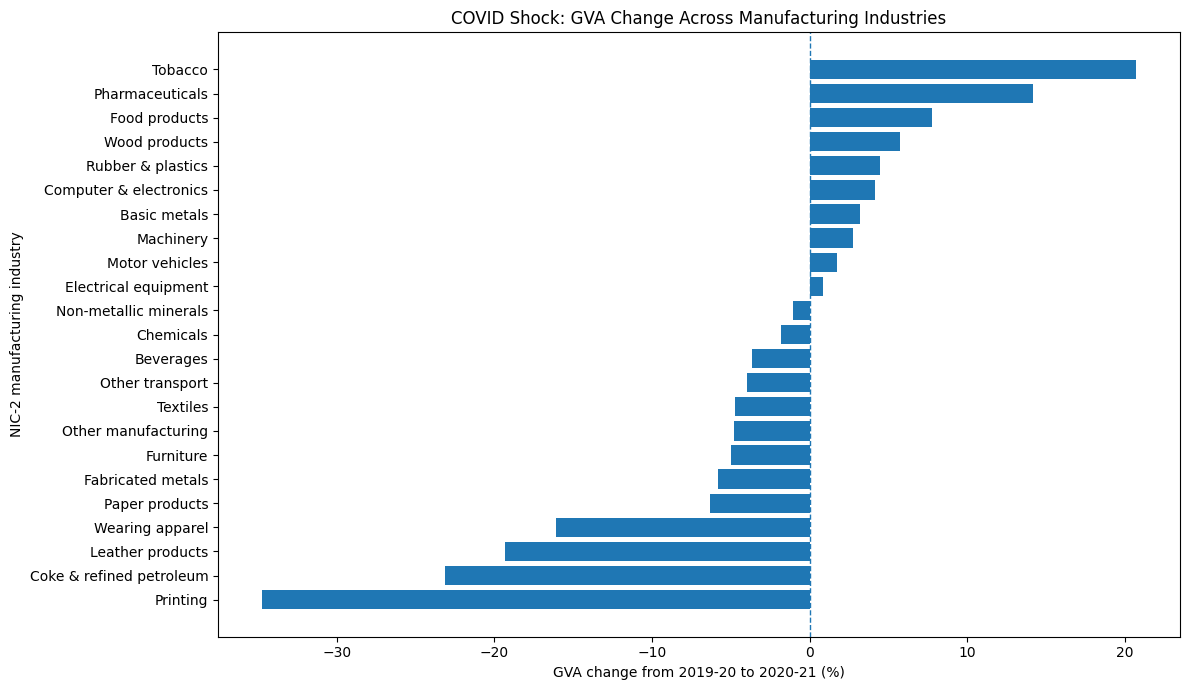

In [ ]:
plot_df = ranking.copy()

plt.figure(figsize=(12, 7))
plt.barh(plot_df["industry_name"], plot_df["gva_drop_pct"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("GVA change from 2019-20 to 2020-21 (%)")
plt.ylabel("NIC-2 manufacturing industry")
plt.title("COVID Shock: GVA Change Across Manufacturing Industries")
plt.tight_layout()
plt.savefig("figures/gva_drop_by_industry.png", dpi=300)
plt.show()

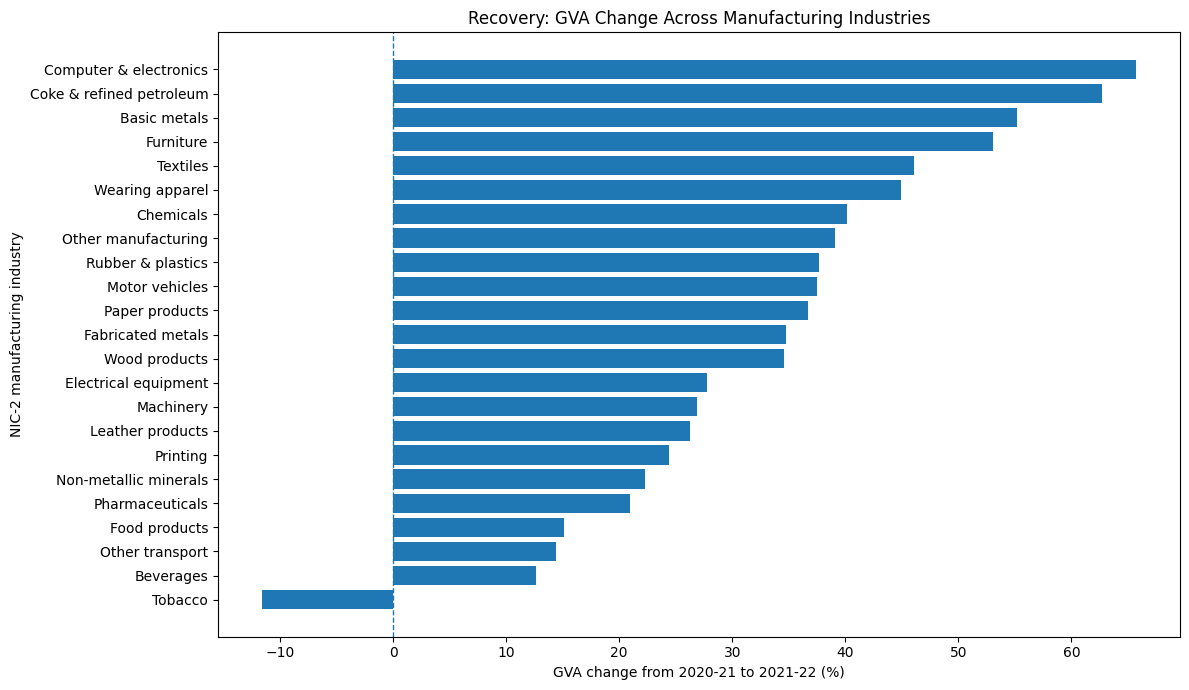

In [ ]:
recovery_df = df.sort_values("gva_recovery_pct")

plt.figure(figsize=(12, 7))
plt.barh(recovery_df["industry_name"], recovery_df["gva_recovery_pct"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("GVA change from 2020-21 to 2021-22 (%)")
plt.ylabel("NIC-2 manufacturing industry")
plt.title("Recovery: GVA Change Across Manufacturing Industries")
plt.tight_layout()
plt.savefig("figures/gva_recovery_by_industry.png", dpi=300)
plt.show()

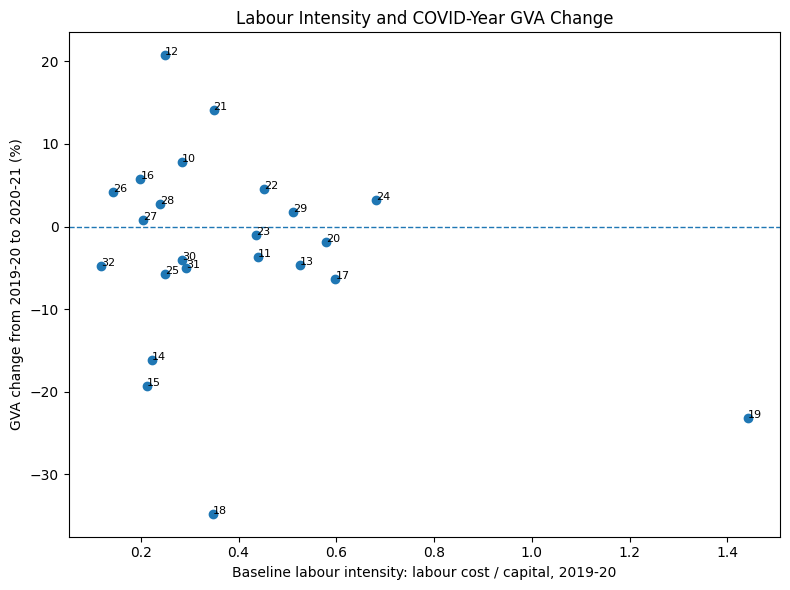

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["labour_intensity_baseline"], df["gva_drop_pct"])

for _, row in df.iterrows():
    plt.text(
        row["labour_intensity_baseline"],
        row["gva_drop_pct"],
        str(int(row["nic2"])),
        fontsize=8
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Baseline labour intensity: labour cost / capital, 2019-20")
plt.ylabel("GVA change from 2019-20 to 2020-21 (%)")
plt.title("Labour Intensity and COVID-Year GVA Change")
plt.tight_layout()
plt.savefig("figures/labour_intensity_vs_gva_drop.png", dpi=300)
plt.show()

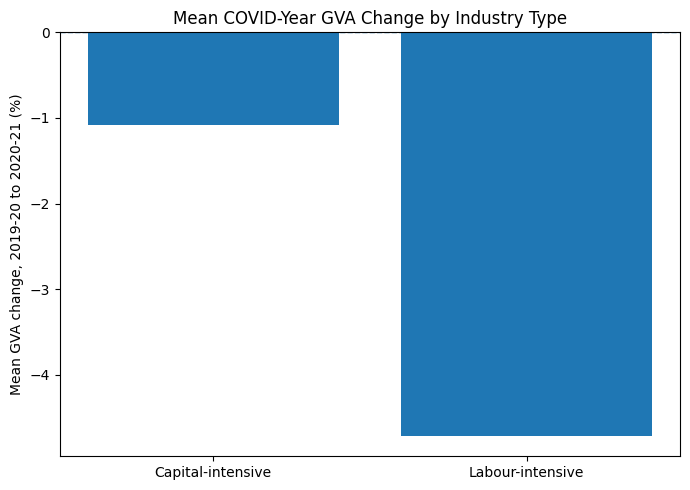

In [ ]:
group_order = ["Capital-intensive", "Labour-intensive"]
means = df.groupby("group")["gva_drop_pct"].mean().reindex(group_order)

plt.figure(figsize=(7, 5))
plt.bar(means.index, means.values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Mean GVA change, 2019-20 to 2020-21 (%)")
plt.title("Mean COVID-Year GVA Change by Industry Type")
plt.tight_layout()
plt.savefig("figures/group_mean_gva_drop.png", dpi=300)
plt.show()

In [ ]:
# Features available before or during baseline classification
features = [
    "labour_intensity_baseline",
    "total_gva20",
    "total_output20",
    "total_labour_cost20",
    "total_capital20",
    "factory_count20",
    "gva_per_labour_cost20",
    "capital_gva_ratio20"
]

model_df = df.dropna(subset=features + ["gva_drop_pct"]).copy()

X = model_df[features]
y = model_df["gva_drop_pct"]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2
)

rf.fit(X, y)

importances = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importances.to_csv("tables/random_forest_feature_importance.csv", index=False)
importances

,feature,importance
5,factory_count20,0.232564
6,gva_per_labour_cost20,0.200025
7,capital_gva_ratio20,0.147641
2,total_output20,0.113808
4,total_capital20,0.111004
1,total_gva20,0.076027
0,labour_intensity_baseline,0.070579
3,total_labour_cost20,0.048353


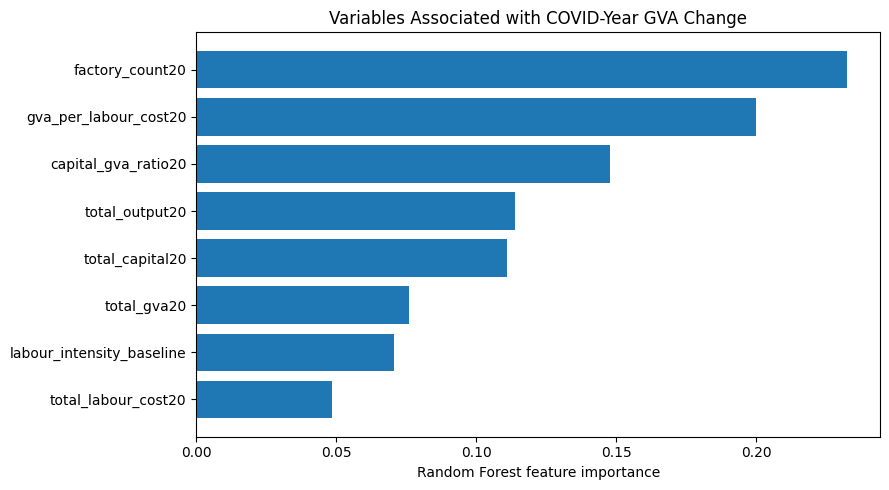

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest feature importance")
plt.title("Variables Associated with COVID-Year GVA Change")
plt.tight_layout()
plt.savefig("figures/random_forest_feature_importance.png", dpi=300)
plt.show()

In [ ]:
manifest = {
    "charter_locked": True,
    "sources": [
        {
            "name": "Annual Survey of Industries, MoSPI",
            "status": "working",
            "probe_artifact": "artifacts/probes/asi_probe.md",
            "note": (
                "ASI Blocks A, C, D, and J were used to construct weighted "
                "NIC-2 manufacturing industry aggregates for 2019-20, 2020-21, "
                "and 2021-22."
            )
        }
    ],
    "baseline_ready": True,
    "primary_metric_schema_ready": True,
    "run_command": "uv run main.py"
}

with open("outputs/milestone_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest

{'charter_locked': True,
 'sources': [{'name': 'Annual Survey of Industries, MoSPI',
   'status': 'working',
   'probe_artifact': 'artifacts/probes/asi_probe.md',
   'note': 'ASI Blocks A, C, D, and J were used to construct weighted NIC-2 manufacturing industry aggregates for 2019-20, 2020-21, and 2021-22.'}],
 'baseline_ready': True,
 'primary_metric_schema_ready': True,
 'run_command': 'uv run main.py'}

In [ ]:
import os

# ============================================================
# Random Forest variable importance
# Purpose: pattern discovery only, not causal inference
# ============================================================

features = [
    "labour_intensity_baseline",
    "total_gva20",
    "total_output20",
    "total_labour_cost20",
    "total_capital20",
    "factory_count20",
    "gva_per_labour_cost20",
    "capital_gva_ratio20"
]

model_df = df.dropna(subset=features + ["gva_drop_pct"]).copy()

X = model_df[features]
y = model_df["gva_drop_pct"]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2
)

rf.fit(X, y)

importances = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importances.to_csv("tables/random_forest_feature_importance.csv", index=False)

importances

,feature,importance
5,factory_count20,0.232564
6,gva_per_labour_cost20,0.200025
7,capital_gva_ratio20,0.147641
2,total_output20,0.113808
4,total_capital20,0.111004
1,total_gva20,0.076027
0,labour_intensity_baseline,0.070579
3,total_labour_cost20,0.048353


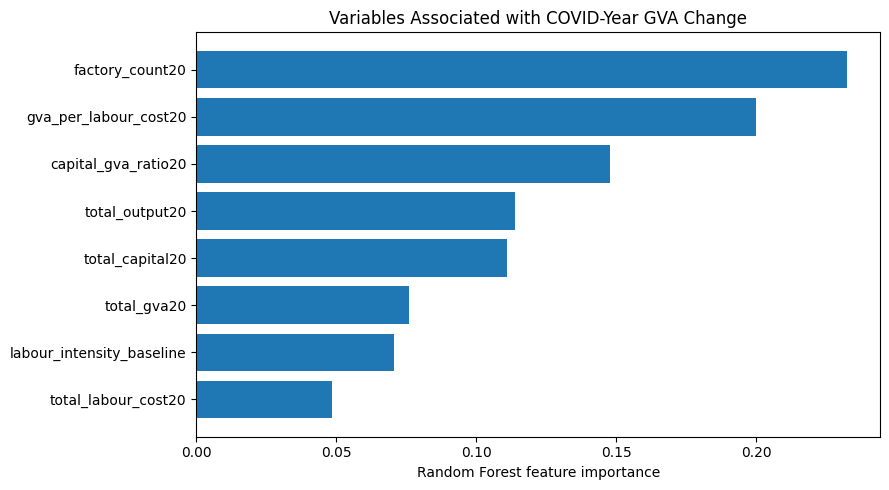

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest feature importance")
plt.title("Variables Associated with COVID-Year GVA Change")
plt.tight_layout()
plt.savefig("figures/random_forest_feature_importance.png", dpi=300)
plt.show()

In [ ]:
manifest = {
    "charter_locked": True,
    "sources": [
        {
            "name": "Annual Survey of Industries, MoSPI",
            "status": "working",
            "probe_artifact": "artifacts/probes/asi_probe.md",
            "note": (
                "ASI Blocks A, C, D, and J were used to construct weighted "
                "NIC-2 manufacturing industry aggregates for 2019-20, 2020-21, "
                "and 2021-22."
            )
        }
    ],
    "baseline_ready": True,
    "primary_metric_schema_ready": True,
    "run_command": "uv run main.py",
    "outputs_created": [
        "outputs/baseline_metric.json",
        "outputs/primary_metric.json",
        "outputs/milestone_manifest.json",
        "tables/descriptive_summary.csv",
        "tables/group_summary.csv",
        "tables/industry_gva_drop_ranking.csv",
        "tables/random_forest_feature_importance.csv",
        "figures/gva_drop_by_industry.png",
        "figures/gva_recovery_by_industry.png",
        "figures/labour_intensity_vs_gva_drop.png",
        "figures/group_mean_gva_drop.png",
        "figures/random_forest_feature_importance.png"
    ]
}

with open("outputs/milestone_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest

{'charter_locked': True,
 'sources': [{'name': 'Annual Survey of Industries, MoSPI',
   'status': 'working',
   'probe_artifact': 'artifacts/probes/asi_probe.md',
   'note': 'ASI Blocks A, C, D, and J were used to construct weighted NIC-2 manufacturing industry aggregates for 2019-20, 2020-21, and 2021-22.'}],
 'baseline_ready': True,
 'primary_metric_schema_ready': True,
 'run_command': 'uv run main.py',
 'outputs_created': ['outputs/baseline_metric.json',
  'outputs/primary_metric.json',
  'outputs/milestone_manifest.json',
  'tables/descriptive_summary.csv',
  'tables/group_summary.csv',
  'tables/industry_gva_drop_ranking.csv',
  'tables/random_forest_feature_importance.csv',
  'figures/gva_drop_by_industry.png',
  'figures/gva_recovery_by_industry.png',
  'figures/labour_intensity_vs_gva_drop.png',
  'figures/group_mean_gva_drop.png',
  'figures/random_forest_feature_importance.png']}